<a href="https://colab.research.google.com/github/Gauranggupta2323/Gaurang_Gupta_JECRC_Foundation_CEI/blob/main/week5_Gaurang_Gupta_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [4]:
corpus = """My interest in deep learning began with small projects; now I focus on text models that predict the next word.
Here I implement and compare Vanilla RNN, LSTM and GRU using a short corpus I wrote myself.
I will use these experiments to observe training behaviour, memory handling, and the quality of generated text."""
print(corpus)

My interest in deep learning began with small projects; now I focus on text models that predict the next word.
Here I implement and compare Vanilla RNN, LSTM and GRU using a short corpus I wrote myself.
I will use these experiments to observe training behaviour, memory handling, and the quality of generated text.


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [6]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 48
X shape: (51, 19)
y shape: (51,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [8]:
rnn_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=1)
print("Vanilla RNN training completed")

d:\Desktop Folders\GitHub Content\Gaurang_Gupta_JECRC_Foundation_CEI\.venv-1\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.0196 - loss: 3.8932
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2353 - loss: 3.6874
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3529 - loss: 3.5255
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4314 - loss: 3.3679
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5294 - loss: 3.2084
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5490 - loss: 3.0410
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6078 - loss: 2.8733
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6275 - loss: 2.7151
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6667 - loss: 2.5565
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7647 - loss: 2.3978
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8235 - loss: 2.2431
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8235 - lo

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [10]:
lstm_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=1)
print("LSTM training completed")

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.0196 - loss: 3.8744
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0588 - loss: 3.8582
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0588 - loss: 3.8440
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0784 - loss: 3.8269
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0588 - loss: 3.8030
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0588 - loss: 3.7662
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0588 - loss: 3.7149
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0588 - loss: 3.6830
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0980 - loss: 3.6565
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1373 - loss: 3.6055
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0980 - loss: 3.5547
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1176 - lo

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [12]:
gru_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=1)
print("GRU training completed")

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.0392 - loss: 3.8741
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1569 - loss: 3.8543
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2941 - loss: 3.8377
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3137 - loss: 3.8210
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2941 - loss: 3.8035
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1961 - loss: 3.7847
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1961 - loss: 3.7641
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1569 - loss: 3.7408
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1765 - loss: 3.7140
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1176 - loss: 3.6821
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1176 - loss: 3.6431
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0980 - lo

## 📉 Compare Training Loss

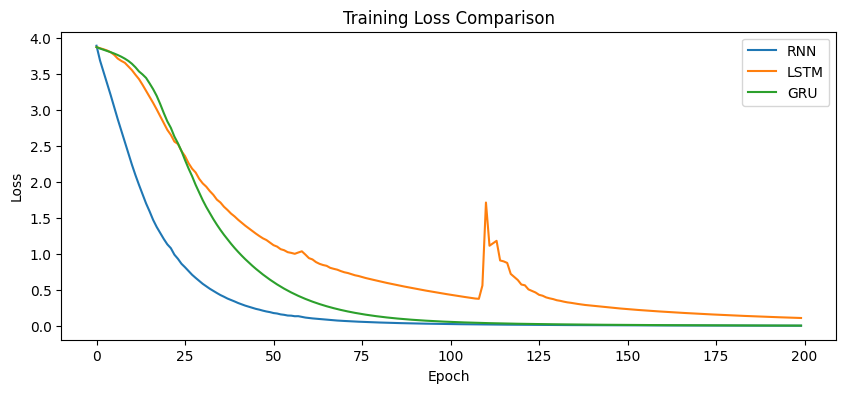

In [14]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [16]:
# build index->word map once
index_word = {index: word for word, index in tokenizer.word_index.items()}

def sample_with_temperature(preds, temperature=1.0):
    preds = np.asarray(preds).astype('float64')
    if temperature <= 0:
        return np.argmax(preds)
    preds = np.log(preds + 1e-9) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    # choose from vocabulary size
    return np.random.choice(len(preds), p=preds)

def generate_text(model, seed_text, next_words=10, temperature=1.0):
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        preds = model.predict(token_list, verbose=0)[0]
        predicted_index = sample_with_temperature(preds, temperature=temperature)
        # map predicted_index to word (tokenizer indices start at 1)
        word = index_word.get(predicted_index, "")
        if word == "":
            # fallback to argmax mapping if sampling picks 0 or unknown
            predicted_index = np.argmax(preds)
            word = index_word.get(predicted_index, "")
        result += " " + word
    return result

## 🧪 Generate Text Samples

In [18]:
seed = "deep learning"
rnn_sample = generate_text(rnn_model, seed, next_words=10, temperature=1.0)
lstm_sample = generate_text(lstm_model, seed, next_words=10, temperature=1.0)
gru_sample = generate_text(gru_model, seed, next_words=10, temperature=1.0)

print("RNN :", rnn_sample)
print("LSTM:", lstm_sample)
print("GRU :", gru_sample)

# Save outputs to a text file for submission or inspection
with open("text_generation_samples.txt", "w", encoding="utf-8") as f:
    f.write("Seed: " + seed + "\n\n")
    f.write("RNN : " + rnn_sample + "\n\n")
    f.write("LSTM: " + lstm_sample + "\n\n")
    f.write("GRU : " + gru_sample + "\n")
print("Samples saved to text_generation_samples.txt")

RNN : deep learning deep these will projects now i now word text models
LSTM: deep learning i these experiments experiments to observe training behaviour memory memory
GRU : deep learning interest in deep learning began with small projects now i
Samples saved to text_generation_samples.txt


In [19]:
# Quick checklist results
print("Vocabulary:", total_words)
print("Max sequence length:", max_len)
print("RNN history epochs:", len(rnn_history.history['loss']))
print("LSTM history epochs:", len(lstm_history.history['loss']))
print("GRU history epochs:", len(gru_history.history['loss']))

Vocabulary: 48
Max sequence length: 20
RNN history epochs: 200
LSTM history epochs: 200
GRU history epochs: 200
